In [1]:
import numpy as np
import matplotlib.pyplot as plt
from zmc import Zmc

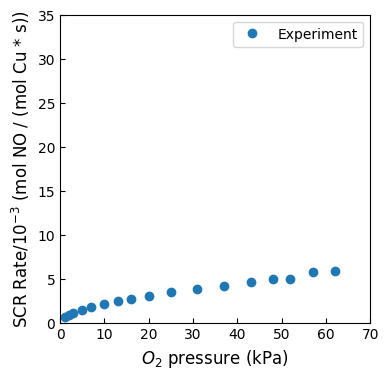

In [29]:
x = np.array([
    1, 2, 3, 5, 7, 10, 13, 16,
    20, 25, 31, 37, 43, 48, 52,
    57, 62
])
y = np.array([
    0.6, 0.9, 1.1, 1.4, 1.8, 2.1, 2.4, 2.7,
    3.0, 3.5, 3.8, 4.2, 4.6, 4.9, 5.0,
    5.7, 5.9
])
plt.figure(figsize=(4,4))
plt.plot(x,y,'o',label='Experiment')
plt.xlim(0,70)
plt.ylim(0,35)
plt.xlabel(r'$O_2$ pressure (kPa)',fontsize=12)
plt.ylabel(r'SCR Rate/$10^{-3}$ (mol NO / (mol Cu * s))',fontsize=12)
plt.tick_params(direction='in')
plt.legend()
plt.show()

# To get the NOx SCR rate

### 2nd order: $r_{ox}^{S.S.}$  = $k_{ox}P_{O2}\frac{\lambda(d)}{Vol.}$ [=] mol NO * 1000 Å ^3 / (mol Cu * kPa O2 * s)
### 1st order: $r_{red}^{S.S.}$ = $k_{red}P_{NO}P_{NH3}$ [=] mol NO / (mol Cu * s)

In [3]:
vol = 1743432.3688417426
k = 0.1
A = k*vol/1e3
print(A)

174.34323688417427


# Positional Argument: Short = False: Normal Code

In [4]:
import time
# Ar ~ k_red
# Ap ~ k_ox
start = time.time()
calc = Zmc(Ar=0.023, Ap=52.103, P_O2=46.9, D=20.0, rho_Cu=0.3499,short=False)
# calc.max_events = 5000000
# calc.wtime = 36000
calc.calculate()
end = time.time()
print(f"Runtime: {end-start:.3f} seconds")

Runtime: 72.854 seconds


In [ ]:
calc.

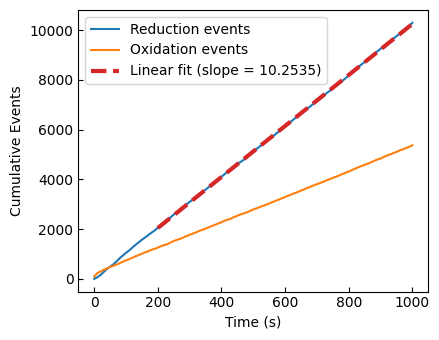

In [5]:
from scipy.stats import linregress

start = len(calc.t) // 5
x = calc.t[start:]
y = calc.rev[start:]
slope, intercept, r_value, p_value, std_err = linregress(x, y)
y_fit = float(slope) * np.array(x) + intercept

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.plot(calc.t, calc.rev, label='Reduction events')
ax.plot(calc.t, calc.oev, label='Oxidation events')
ax.plot(x, y_fit, color='tab:red', linewidth=3, linestyle='--',
      label=f'Linear fit (slope = {slope:.4f})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cumulative Events')
ax.tick_params(direction='in')
ax.legend()
fig.tight_layout()
plt.show()

In [6]:
r = slope / calc.NCu
print(rf'SCR rate: {r:.4f} mol NO / (mol Cu * S)')

SCR rate: 0.0168 mol NO / (mol Cu * S)


In [7]:
# Author's method
ss_fraction, _, _, _ =calc.get_fraction()
ss_rate = calc.get_rate()
print(f'Fraction of Cu(II): {ss_fraction:.3f}')
print(f'SCR rate: {ss_rate:.4f}')

Simulation sufficiently converged. Calculating averages
Fraction of Cu(II): 0.739
SCR rate: 0.0168


# To get the Cu (I) and Cu (II) fractions

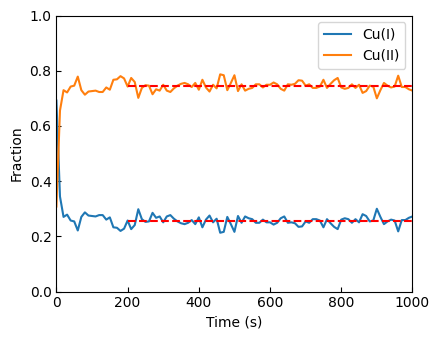

In [8]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
N_CuI = np.array(calc.o)
N_CuII = np.array(calc.tw)
ax.plot(calc.t, N_CuI/calc.NCu, label='Cu(I)')
ax.plot(calc.t, N_CuII/calc.NCu, label='Cu(II)')

fract_I = np.average(N_CuI[start:])/calc.NCu
fract_II = np.average(N_CuII[start:])/calc.NCu

ax.hlines(y=fract_I, xmin=calc.t[start], xmax=calc.t[-1], color='r', linestyle='--')
ax.hlines(y=fract_II, xmin=calc.t[start], xmax=calc.t[-1], color='r', linestyle='--')

ax.set_ylim(0,1)
ax.set_xlim(0,calc.t[-1])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Fraction')
ax.tick_params(direction='in')
ax.legend()
fig.tight_layout()
plt.show()

In [9]:
print(f'SS Cu I fraction : {fract_I:.3f}')
print(f'SS Cu II fraction: {fract_II:.3f}')

SS Cu I fraction : 0.255
SS Cu II fraction: 0.745


# Positional Argument: Short = True

In [10]:
import time
# Ar ~ k_red
# Ap ~ k_ox
start = time.time()
calc = Zmc(Ar=0.023, Ap=52.103, P_O2=46.9, D=20.0, rho_Cu=0.3499,short=True)
# calc.max_events = 5000000
# calc.wtime = 36000
calc.calculate()
end = time.time()
print(f"Runtime: {end-start:.3f} seconds")

Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Runtime: 39.942 seconds


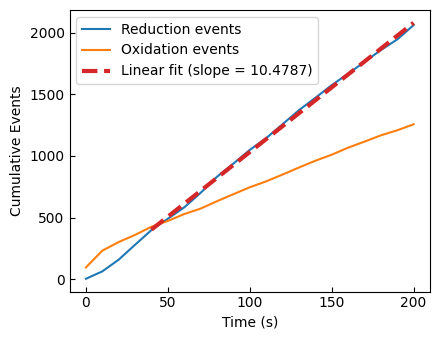

In [11]:
from scipy.stats import linregress

start = len(calc.t) // 5
x = calc.t[start:]
y = calc.rev[start:]
slope, intercept, r_value, p_value, std_err = linregress(x, y)
y_fit = float(slope) * np.array(x) + intercept

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.plot(calc.t, calc.rev, label='Reduction events')
ax.plot(calc.t, calc.oev, label='Oxidation events')
ax.plot(x, y_fit, color='tab:red', linewidth=3, linestyle='--',
      label=f'Linear fit (slope = {slope:.4f})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cumulative Events')
ax.tick_params(direction='in')
ax.legend()
fig.tight_layout()
plt.show()

In [12]:
ss_fraction, _, _, _ =calc.get_fraction()
ss_rate = calc.get_rate()
print(f'Fraction of Cu(II): {ss_fraction:.3f}')
print(f'SCR rate: {ss_rate:.4f}')

Simulation sufficiently converged. Calculating averages
Fraction of Cu(II): 0.717
SCR rate: 0.0173


# Effect of $k_{ox}$
### Goswami et al.: 0 < $k_{ox}$ < 0.2
Variables:

$k_{ox}$ = 0.05, 0.1, 0.15

$k_{red}$ = 0.1

$D$ = 20

In [25]:
# Obtained from CRC
k_oxidation = {}
k_oxidation['0.05'] = {}
k_oxidation['0.05']['P'] = [0,1.0, 7.6, 14.1, 20.7, 27.2, 33.8, 40.3, 46.9, 53.4, 60.0]
k_oxidation['0.05']['r'] = [0,0.0025662285771152764, 0.014738386597280417, 0.022652152578341005, 0.028413160457495434, 0.03272904945623446, 0.03640475392366822, 0.03864084643758495, 0.04093977065049306, 0.04326975009874213, 0.04504840064525047]
k_oxidation['0.05']['f'] = [0,0.02257799671592775, 0.1471264367816092, 0.24201787994891444, 0.2926613616268789, 0.359514687100894, 0.3883415435139573, 0.3950524737631184, 0.41345503718728877, 0.4434865900383141, 0.4592911877394637]
k_oxidation['0.10'] = {}
k_oxidation['0.10']['P'] = [0,1.0, 7.6, 14.1, 20.7, 27.2, 33.8, 40.3, 46.9, 53.4, 60.0]
k_oxidation['0.10']['r'] = [0,0.004736970938473158, 0.023771294274315957, 0.033365088800969354, 0.03892423211866957, 0.04353797387852377, 0.04710261147818638, 0.05001786060959039, 0.05238105088399308, 0.05451287664263385, 0.05626783550566011]
k_oxidation['0.10']['f'] = [0,0.05003380662609871, 0.2327586206896551, 0.321360153256705, 0.40229885057471254, 0.44795657726692206, 0.4727011494252874, 0.51105216622458, 0.5344827586206896, 0.5459770114942529, 0.5761494252873564]

k_oxidation['0.15'] = {}
k_oxidation['0.15']['P'] = [0,1.0, 7.6, 14.1, 20.7, 27.2, 33.8, 40.3, 46.9, 53.4, 60.0]
k_oxidation['0.15']['r'] = [0,0.006860437971344595, 0.029821955562696234, 0.03942753585703396, 0.045665515233064904, 0.05019512113483155, 0.053744575877466054, 0.05631975712784261, 0.05874642352673404, 0.06044713781723002, 0.062389954411262646]
k_oxidation['0.15']['f'] = [0,0.06426332288401254, 0.2995689655172414, 0.3874521072796934, 0.4733169129720853, 0.5057471264367815, 0.5450928381962865, 0.5611285266457681, 0.5919540229885057, 0.6016799292661361, 0.6243842364532021]

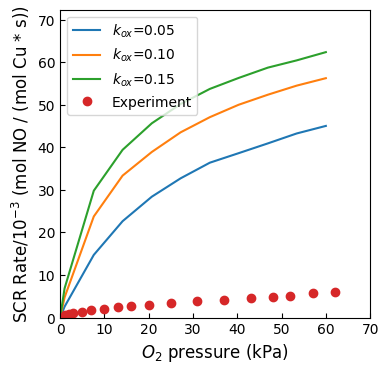

In [30]:
plt.figure(figsize=(4,4))
plt.plot(k_oxidation['0.05']['P'],np.array(k_oxidation['0.05']['r'])*1e3,label=r'$k_{ox}$=0.05')
plt.plot(k_oxidation['0.10']['P'],np.array(k_oxidation['0.10']['r'])*1e3,label=r'$k_{ox}$=0.10')
plt.plot(k_oxidation['0.15']['P'],np.array(k_oxidation['0.15']['r'])*1e3,label=r'$k_{ox}$=0.15')
plt.plot(x,y,'o',label='Experiment')

plt.xlim(0,70)
plt.ylim(0,np.array(k_oxidation['0.15']['r'][-1])*1e3+10)
plt.xlabel(r'$O_2$ pressure (kPa)',fontsize=12)
plt.ylabel(r'SCR Rate/$10^{-3}$ (mol NO / (mol Cu * s))',fontsize=12)
plt.tick_params(direction='in')
plt.legend()
plt.show()

# Effect of $k_{red}$
### Goswami et al.: 0 < $k_{red}$ < 0.2
Variables:

$k_{ox}$ = 0.1

$k_{red}$ = 0.05, 0.1, 0.15

$D$ = 20

In [33]:
k_reduction = {}
k_reduction['0.05'] = {}
k_reduction['0.05']['P'] = [0,1.0, 7.6, 14.1, 20.7, 27.2, 33.8, 40.3, 46.9, 53.4, 60.0]
k_reduction['0.05']['r'] = [0,0.0043499342474711935, 0.017290035815250383, 0.022509666686749818, 0.025724051573514355, 0.027913473781455235, 0.02960101620709739, 0.030177514911734593, 0.03133637258249153, 0.03212507112780245, 0.0327813815864345]
k_reduction['0.05']['f'] = [0,0.08860153256704978, 0.34961685823754785, 0.4557471264367816, 0.5156739811912225, 0.5369458128078818, 0.5804597701149427, 0.6081007115489875, 0.6285919540229885, 0.6229000884173299, 0.6706646676661671]
k_reduction['0.10'] = {}
k_reduction['0.10']['P'] = [0,1.0, 7.6, 14.1, 20.7, 27.2, 33.8, 40.3, 46.9, 53.4, 60.0]
k_reduction['0.10']['r'] = [0,0.004736970938473158, 0.023771294274315957, 0.033365088800969354, 0.03892423211866957, 0.04353797387852377, 0.04710261147818638, 0.05001786060959039, 0.05238105088399308, 0.05451287664263385, 0.05626783550566011]
k_reduction['0.10']['f'] = [0,0.05003380662609871, 0.2327586206896551, 0.321360153256705, 0.40229885057471254, 0.44795657726692206, 0.4727011494252874, 0.51105216622458, 0.5344827586206896, 0.5459770114942529, 0.5761494252873564]
k_reduction['0.15'] = {}
k_reduction['0.15']['P'] = [0,1.0, 7.6, 14.1, 20.7, 27.2, 33.8, 40.3, 46.9, 53.4, 60.0]
k_reduction['0.15']['r'] = [0,0.004914781823009885, 0.027245902703860653, 0.03957747742319872, 0.048453686747985135, 0.05516844402492989, 0.060755360525910615, 0.06541687103263456, 0.06932347027806225, 0.07246489131671789, 0.07551266242242888]
k_reduction['0.15']['f'] = [0,0.03895274584929758, 0.1788370520622042, 0.26781609195402295, 0.3336713995943205, 0.37164750957854403, 0.3876698014629049, 0.4456635318704283, 0.47701149425287365, 0.4964328180737217, 0.49856321839080464]

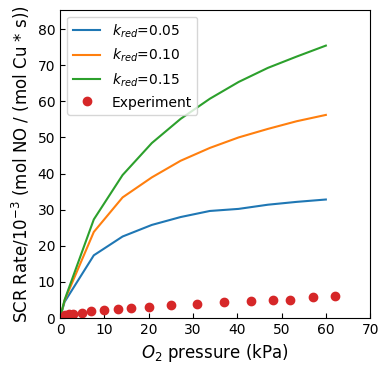

In [34]:
plt.figure(figsize=(4,4))
plt.plot(k_reduction['0.05']['P'],np.array(k_reduction['0.05']['r'])*1e3,label=r'$k_{red}$=0.05')
plt.plot(k_reduction['0.10']['P'],np.array(k_reduction['0.10']['r'])*1e3,label=r'$k_{red}$=0.10')
plt.plot(k_reduction['0.15']['P'],np.array(k_reduction['0.15']['r'])*1e3,label=r'$k_{red}$=0.15')
# plt.plot(x,y,'o',label='Experiment')

plt.xlim(0,70)
plt.ylim(0,np.array(k_reduction['0.15']['r'][-1])*1e3+10)
plt.xlabel(r'$O_2$ pressure (kPa)',fontsize=12)
plt.ylabel(r'SCR Rate/$10^{-3}$ (mol NO / (mol Cu * s))',fontsize=12)
plt.tick_params(direction='in')
plt.legend()
plt.show()

# Effect of $D$
### Goswami et al.: 0 < $D$ < 60 Å
Variables:

$k_{ox}$ = 0.1

$k_{red}$ = 0.1

$D$ = 10, 15, 20

In [23]:
k_D = {}
k_D['15'] = {}
k_D['15']['P'] = [1.0, 7.6, 14.1, 20.7, 27.2, 33.8, 40.3, 46.9, 53.4, 60.0]
k_D['15']['r'] = [0.0021646534947075166, 0.012750743695059158, 0.019887581089345505, 0.025167353510198893, 0.029386295262386286, 0.03284225852070533, 0.035660884060008446, 0.03823437542206014, 0.03971374825109287, 0.04138737707442146]
k_D['15']['f'] = [0.019157088122605366, 0.13669950738916256, 0.19721718088324258, 0.24493705528188287, 0.2916666666666667, 0.34564860426929395, 0.37859195402298845, 0.35632183908045983, 0.4053236539624924, 0.40539345711759506]
k_D['10'] = {}
k_D['10']['P'] = [1.0, 7.6, 14.1, 20.7, 27.2, 33.8, 40.3, 46.9, 53.4, 60.0]
k_D['10']['r'] = [0.0006258531654382478, 0.004285607749415916, 0.0073945070369105855, 0.010208153313572029, 0.012633946153236012, 0.014775287373471804, 0.016824076342725557, 0.018612946933638602, 0.020246906333443327, 0.02176447610278269]
k_D['10']['f'] = [0.009222133119486763, 0.0388817936710657, 0.07036346691519105, 0.10063718140929534, 0.14080459770114945, 0.14821536600120994, 0.17392619479733817, 0.18877099911582665, 0.19923371647509577, 0.2086925287356322]
k_D['20'] = {}
k_D['20']['P'] = [0,1.0, 7.6, 14.1, 20.7, 27.2, 33.8, 40.3, 46.9, 53.4, 60.0]
k_D['20']['r'] = [0,0.004736970938473158, 0.023771294274315957, 0.033365088800969354, 0.03892423211866957, 0.04353797387852377, 0.04710261147818638, 0.05001786060959039, 0.05238105088399308, 0.05451287664263385, 0.05626783550566011]
k_D['20']['f'] = [0,0.05003380662609871, 0.2327586206896551, 0.321360153256705, 0.40229885057471254, 0.44795657726692206, 0.4727011494252874, 0.51105216622458, 0.5344827586206896, 0.5459770114942529, 0.5761494252873564]

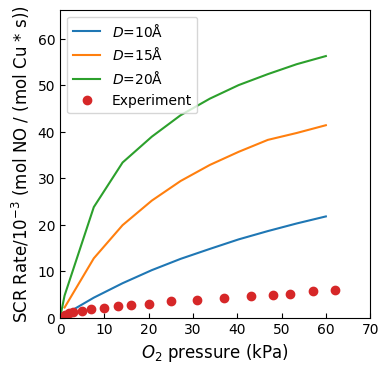

In [32]:
plt.figure(figsize=(4,4))
plt.plot(k_D['10']['P'],np.array(k_D['10']['r'])*1e3,label=r'$D$=10Å')
plt.plot(k_D['15']['P'],np.array(k_D['15']['r'])*1e3,label=r'$D$=15Å')
plt.plot(k_D['20']['P'],np.array(k_D['20']['r'])*1e3,label=r'$D$=20Å')
# plt.plot(x,y,'o',label='Experiment')

plt.xlim(0,70)
plt.ylim(0,np.array(k_D['20']['r'][-1])*1e3+10)
plt.xlabel(r'$O_2$ pressure (kPa)',fontsize=12)
plt.ylabel(r'SCR Rate/$10^{-3}$ (mol NO / (mol Cu * s))',fontsize=12)
plt.tick_params(direction='in')
plt.legend()
plt.show()